In [1]:

import tensorflow as tf
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

I0000 00:00:1785144372.952471  358316 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785144373.812950  358316 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785144380.172364  358316 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPUs: []


E0000 00:00:1785143752.407938  346793 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
metadata = pd.read_csv("Datasets/HAM10000_metadata.csv")

In [4]:
import glob
import os

image_paths = {}

for folder in [
    "Datasets/HAM10000_images_part_1",
    "Datasets/HAM10000_images_part_2"
]:
    for img in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(img))[0]
        image_paths[image_id] = img

metadata["path"] = metadata["image_id"].map(image_paths)

In [5]:
metadata["path"].head()

0    Datasets/HAM10000_images_part_1/ISIC_0027419.jpg
1    Datasets/HAM10000_images_part_1/ISIC_0025030.jpg
2    Datasets/HAM10000_images_part_1/ISIC_0026769.jpg
3    Datasets/HAM10000_images_part_1/ISIC_0025661.jpg
4    Datasets/HAM10000_images_part_2/ISIC_0031633.jpg
Name: path, dtype: str

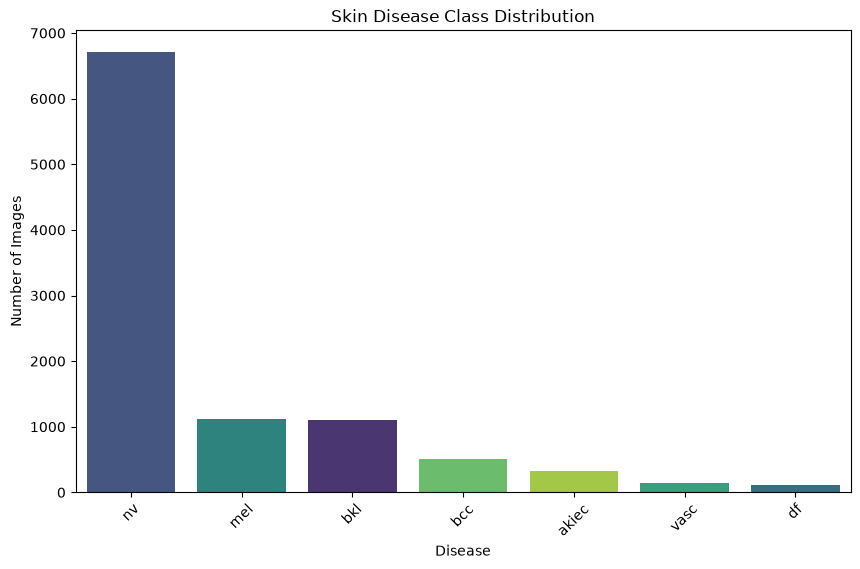

In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x="dx",
    data=metadata,
    hue="dx",
    order=metadata["dx"].value_counts().index,
    palette="viridis",
    legend=False
)

plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [7]:
#Pixel Intensity Analysis
sample_images = metadata.sample(100, random_state=42)
pixel_values = []

for path in sample_images["path"]:

    image = cv2.imread(path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#RGB Channel Distribution
r = []
g = []
b = []

for path in metadata.sample(100)["path"]:

    image = cv2.imread(path)

    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    r.extend(image[:,:,0].flatten())
    g.extend(image[:,:,1].flatten())
    b.extend(image[:,:,2].flatten())
    image = image / 255.0

    pixel_values.extend(image.flatten())

In [8]:
#Image Augmentation Comparison
augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

In [9]:
#Load one image.
image = cv2.imread(metadata.iloc[0]["path"])

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = cv2.resize(image,(224,224))

image = image /255.0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10250503..1.0268563].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12170088..1.0277232].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13738614..1.0123763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.089383006..1.0372881].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10693085..1.0270782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13958997..1.0218155].


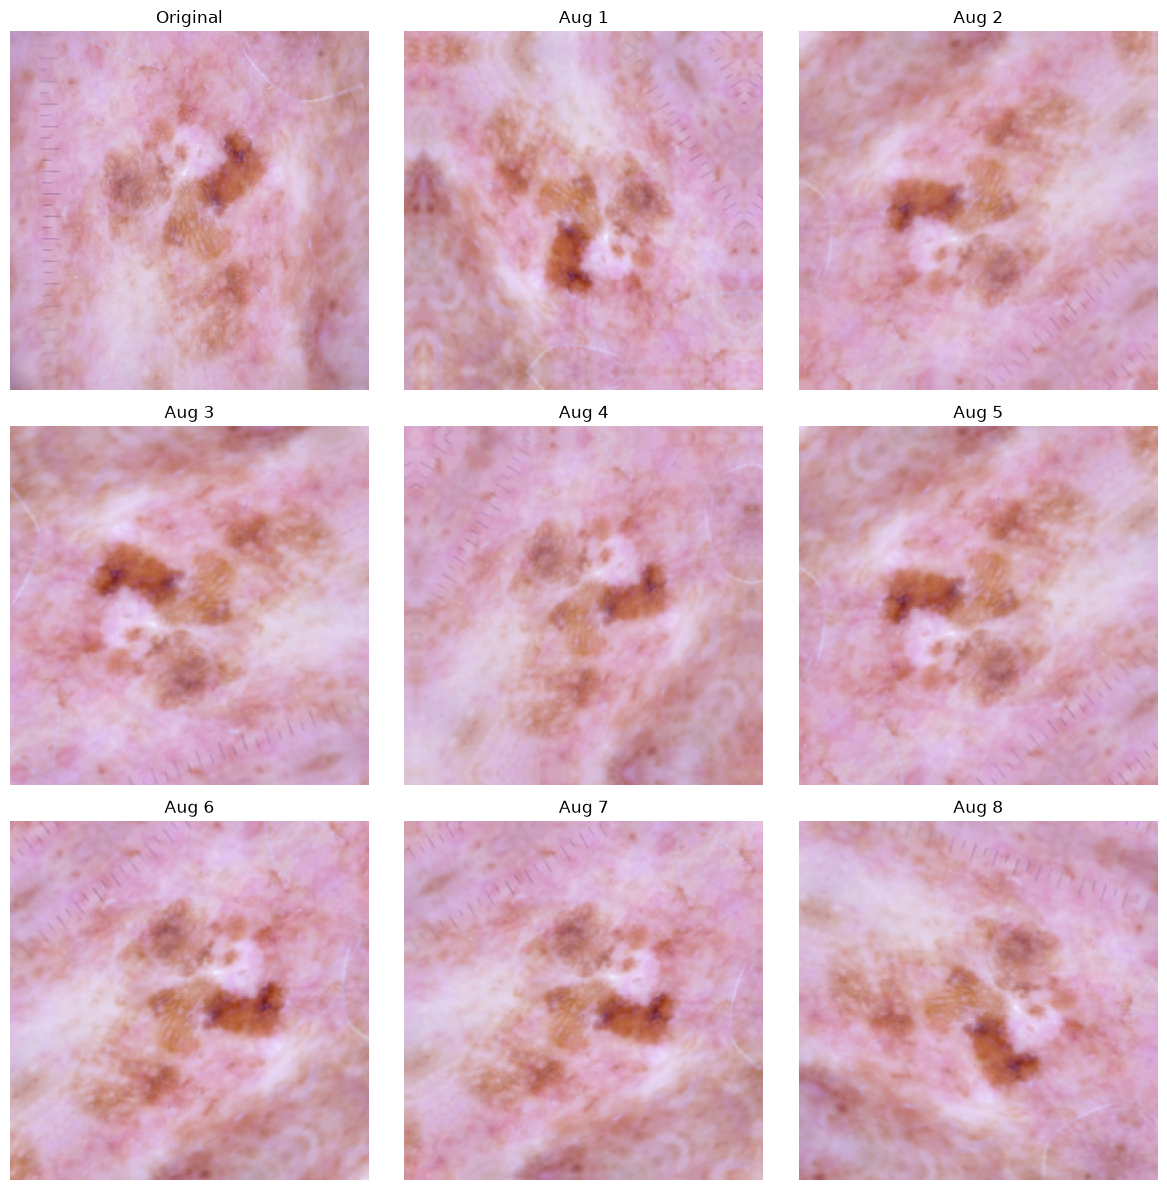

In [10]:
#Generate augmented images.
plt.figure(figsize=(12,12))

plt.subplot(3,3,1)

plt.imshow(image)

plt.title("Original")

plt.axis("off")

for i in range(8):

    aug = augmentation(
        tf.expand_dims(image,0)
    )

    plt.subplot(3,3,i+2)

    plt.imshow(aug[0])

    plt.axis("off")

    plt.title(f"Aug {i+1}")

plt.tight_layout()

plt.show()

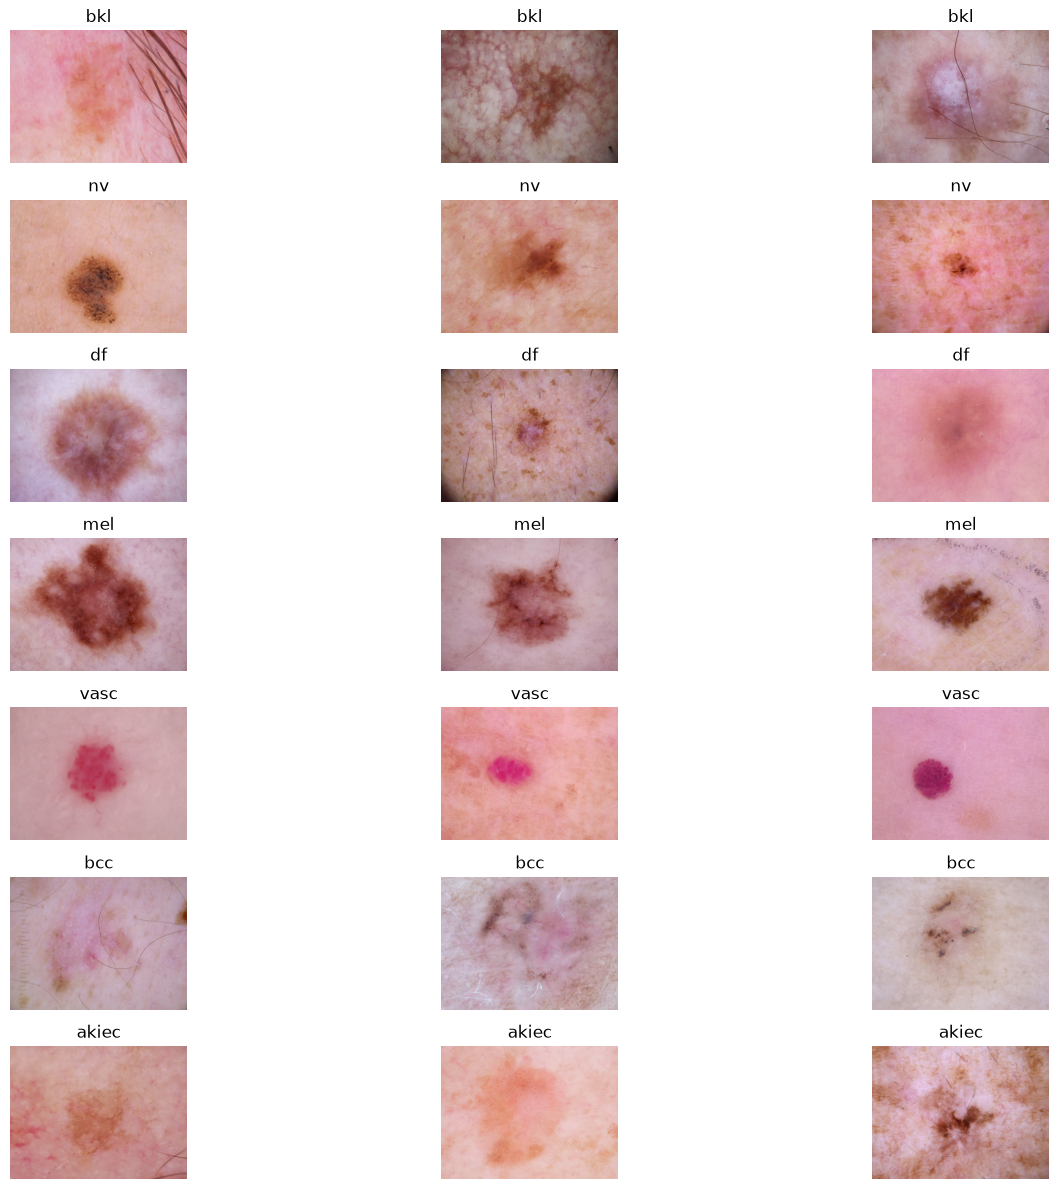

In [11]:
#Class-wise Image Characteristics
classes = metadata["dx"].unique()

plt.figure(figsize=(15,12))

index = 1

for disease in classes:

    sample = metadata[
        metadata["dx"]==disease
    ].sample(3)

    for _, row in sample.iterrows():

        image = cv2.imread(row["path"])

        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        plt.subplot(
            len(classes),
            3,
            index
        )

        plt.imshow(image)

        plt.title(disease)

        plt.axis("off")

        index +=1

plt.tight_layout()

plt.show()

In [12]:
#Average Image Brightness
brightness = []

for path in metadata["path"]:

    image = cv2.imread(path)

    image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    brightness.append(image.mean())

metadata["Brightness"] = brightness

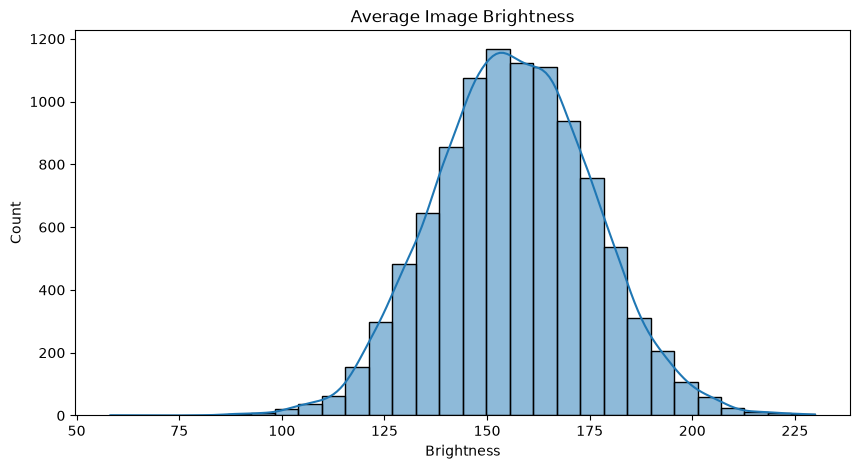

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    metadata["Brightness"],
    bins=30,
    kde=True
)

plt.title("Average Image Brightness")

plt.show()

In [2]:
#RGB Channel Distribution
r = []
g = []
b = []
for path in metadata.sample(20, random_state=42)["path"]:

    image = cv2.imread(path)

    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    r.extend(image[:,:,0].flatten())
    g.extend(image[:,:,1].flatten())
    b.extend(image[:,:,2].flatten())

NameError: name 'metadata' is not defined

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(r,bins=50,alpha=0.5,label="Red")

plt.hist(g,bins=50,alpha=0.5,label="Green")

plt.hist(b,bins=50,alpha=0.5,label="Blue")

plt.legend()

plt.title("RGB Pixel Distribution")

plt.show()